---
## Credit Risk - Artificial Neural Network
---

## 0. Imports & Setup

>Before anything else, we bring in all the libraries we'll need throughout this notebook. Nothing unusual here, the key addition compared to the Decision Tree notebook is `StandardScaler`, which we'll use to normalize the input features before feeding them to the network (more on why in a moment), and `MLPClassifier`, which is scikit-learn's implementation of a feedforward neural network.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

randomize = 20900 

## 1. Load and Preprocess Data
>We load the same `History.csv` dataset used in the Decision Tree notebook which contains 1,000 past loan applicants with known outcomes. A quick `dropna()` removes any rows with missing values before we do anything else.

In [2]:
df = pd.read_csv('History.csv', header=0)
new_df = df.dropna()
new_df

,age,amount,checking,coapp,credit_cards_other_banks,depends,duration,employed,existcr,foreign,...,housing,installp,job,marital,property,purpose,resident,savings,telephon,Good_Bad
0,67,1169,1,1,3,1,6,5,2,0,...,2,4,3,3,1,3,4,5,1,0
1,22,5951,2,1,3,1,48,3,1,0,...,2,2,3,2,1,3,2,1,0,1
2,49,2096,2,1,3,2,12,4,1,0,...,2,2,2,3,1,6,3,1,0,0
3,45,7882,1,3,3,2,42,4,1,0,...,3,2,3,3,2,2,4,1,0,0
4,53,4870,1,1,3,2,24,3,2,0,...,3,3,3,3,4,0,4,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,1736,4,1,3,1,12,4,1,0,...,2,3,2,2,1,2,4,1,0,0
996,40,3857,1,1,3,1,30,3,1,0,...,2,4,4,1,2,1,4,1,1,0
997,38,804,4,1,3,1,12,5,1,0,...,2,4,3,3,3,3,4,1,0,0
998,23,1845,1,1,3,1,45,3,1,0,...,3,4,3,3,4,3,4,1,1,1


>The data pre-processing steps are:
>
>- **Ordinal encoding** for `checking`, `employed`, `savings`, and `credit_cards_other_banks` becasue these variables have a natural order, so we preserve that ranking rather than treating them as unrelated categories.
>- **One-Hot encoding** for the remaining nominal variables (`coapp`, `history`, `housing`, `job`, `marital`, `purpose`, `property`) there's no meaningful order, so each category gets its own binary colum
>- The original raw columns are then dropped and replaced by their encoded counterparts.


In [3]:
X = new_df.iloc[:, :-1].copy()
Y = new_df['Good_Bad']

# Ordinal encoding
ordinal_encoder_checking = OrdinalEncoder(categories=[[1, 2, 3, 4]])
ordinal_encoder_employed = OrdinalEncoder(categories=[[1, 2, 3, 4, 5]])
ordinal_encoder_savings = OrdinalEncoder(categories=[[1, 2, 3, 4, 5]])
ordinal_encoder_credits = OrdinalEncoder(categories=[[0, 1, 2, 3]])

X['employed_encoded'] = ordinal_encoder_employed.fit_transform(X[['employed']])
X['checking_encoded'] = ordinal_encoder_checking.fit_transform(X[['checking']])
X['savings_encoded'] = ordinal_encoder_savings.fit_transform(X[['savings']])
X['credit_cards_other_banks_enc'] = ordinal_encoder_credits.fit_transform(X[['credit_cards_other_banks']])

nominal = ['coapp', 'history', 'housing', 'job', 'marital', 'purpose', 'property']
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_nominal_encoded = ohe.fit_transform(X[nominal])
encoded_cols = ohe.get_feature_names_out(nominal)
X_nominal_encoded = pd.DataFrame(X_nominal_encoded, columns=encoded_cols)

X = X.drop(columns=['employed', 'checking', 'savings', 'credit_cards_other_banks'] + nominal)
X = pd.concat([X, X_nominal_encoded], axis=1)
print(f'Feature matrix shape: {X.shape}')

Feature matrix shape: (1000, 45)


In [4]:
# Train / Validation / Test split  (70 / 15 / 15), same as DT notebook (also stratified)
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, stratify=Y, random_state=randomize)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=randomize)

## 2. Feature Scaling
>Neural networks are sensitive to the scale of their inputs. For example, a feature measured in thousands (like loan amount) would otherwise dominate features measured in single digits (like number of dependents), simply because of its larger numeric range. `StandardScaler` fixes this by transforming every feature to have zero mean and unit variance.
>
>One important detail: we fit the scaler only on the training set and then apply the same transformation to the validation and test sets. This prevents any information from the validation or test data leaking into the scaling parameters.

In [5]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

## 3. ANN Architecture Search: Reduced Error Plot (MSE)
>Rather than just picking an arbitrary network size, we do a more proper search. We train networks with hidden layers ranging from 2 to 40 neurons (in steps of 2) and record the training and validation MSE for each. We want to find the point where validation error is lowest before the model starts overfitting.
>
>The `early_stopping` parameter is turned off during this search so that every network is trained for the full 500 iterations, making the comparison fair across architectures. We then pick the architecture with the lowest validation MSE as our candidate for the final model.

Best hidden layer size (min val MSE): 14 neurons
Minimum validation MSE: 0.2533


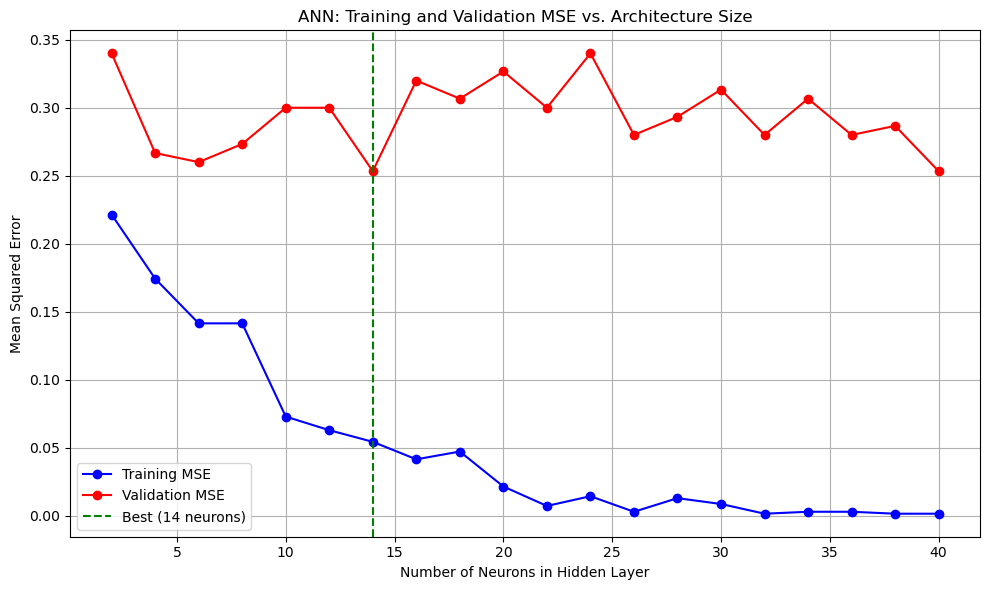

In [6]:
train_errors = []
val_errors = []
neuron_counts = list(range(2, 41, 2))   # 2, 4, 6, ....., 40

for n in neuron_counts:
    ann = MLPClassifier(hidden_layer_sizes=(n,),
                        activation='relu',
                        solver='adam',
                        max_iter=500,
                        early_stopping=False,
                        random_state=randomize)
    ann.fit(X_train_s, Y_train)
    train_errors.append(mean_squared_error(Y_train, ann.predict(X_train_s)))
    val_errors.append(mean_squared_error(Y_val, ann.predict(X_val_s)))

best_n = neuron_counts[np.argmin(val_errors)]
min_val_mse = min(val_errors)
print(f'Best hidden layer size (min val MSE): {best_n} neurons')
print(f'Minimum validation MSE: {min_val_mse:.4f}')

plt.figure(figsize=(10, 6))
plt.plot(neuron_counts, train_errors, marker='o', color='blue', label='Training MSE')
plt.plot(neuron_counts, val_errors,   marker='o', color='red',  label='Validation MSE')
plt.axvline(best_n, color='green', linestyle='--', label=f'Best ({best_n} neurons)')
plt.xlabel('Number of Neurons in Hidden Layer')
plt.ylabel('Mean Squared Error')
plt.title('ANN: Training and Validation MSE vs. Architecture Size')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 4. Optimal ANN: Final Training
>Now that we know the best architecture, we need to  retrain the network with two key changes compared to the search above.
>- The maximum number of iterations is increased to 1,000 to give the network more room to converge properly.
>- Early stopping is now switched on and this holds back 10% of the training data as an internal validation set and stops training automatically if the error stops improving for 20 consecutive iterations. One can think of this as the ANN's version of pruning: it prevents the network from over-learning the training data.

In [7]:
ann_opt = MLPClassifier(hidden_layer_sizes=(best_n,),
                        activation='relu',
                        solver='adam',
                        max_iter=1000,
                        early_stopping=True,        # hold out 10% of training for internal validation
                        validation_fraction=0.1,
                        n_iter_no_change=20,        # stop if no improvement for 20 consecutive epochs
                        random_state=randomize)
ann_opt.fit(X_train_s, Y_train)
print(f'training was stopped at iteration: {ann_opt.n_iter_}')

training was stopped at iteration: 86


## 5. Cut-off Point (same as DT: 0.2857)
>The profit-matrix cut-off of 0.2857 derived in the DT analysis is applied here too.

In [8]:
cut_off = 0.2857

# Test-set predictions
pred_proba_ann = ann_opt.predict_proba(X_test_s)[:, 1]
y_pred_ann = (pred_proba_ann >= cut_off).astype(int)

# MSE comparison
mse_ann = mean_squared_error(Y_test, y_pred_ann)
print(f'ANN Test MSE  (cut-off={cut_off}): {mse_ann:.4f}')

# AUC
auc_ann = roc_auc_score(Y_test, pred_proba_ann)
print(f'ANN AUC-ROC: {auc_ann:.4f}')

ANN Test MSE  (cut-off=0.2857): 0.2333
ANN AUC-ROC: 0.8468


## 6. ANN ROC Curve

>The ROC curve plots the True Positive Rate (correctly identified bad borrowers) against the False Positive Rate (good borrowers incorrectly flagged as bad) across every possible classification threshold. The further the curve bows toward the top-left corner, the better. a model that hugs that corner is catching most of the bad borrowers while barely touching the good ones.

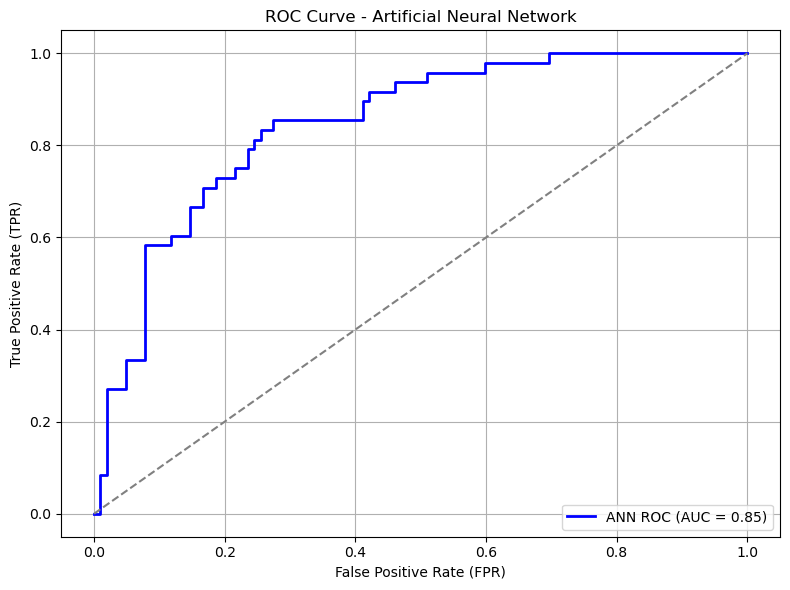

In [9]:
fpr_ann, tpr_ann, _ = roc_curve(Y_test, pred_proba_ann)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ann, tpr_ann, color='blue', lw=2,
         label=f'ANN ROC (AUC = {auc_ann:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - Artificial Neural Network')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Score Future Applicants with the ANN

In [11]:
df_future = pd.read_csv('Future.csv', header=0)
df_future = df_future.dropna()

df_future['employed_encoded'] = ordinal_encoder_employed.transform(df_future[['employed']])
df_future['checking_encoded'] = ordinal_encoder_checking.transform(df_future[['checking']])
df_future['savings_encoded'] = ordinal_encoder_savings.transform(df_future[['savings']])
df_future['credit_cards_other_banks_enc'] = ordinal_encoder_credits.transform(df_future[['credit_cards_other_banks']])

X_future_enc = ohe.transform(df_future[nominal])
X_future_enc = pd.DataFrame(X_future_enc, columns=encoded_cols, index=df_future.index)

df_future = df_future.drop(columns=['employed', 'checking', 'savings', 'credit_cards_other_banks'] + nominal)
df_future = pd.concat([df_future, X_future_enc], axis=1)

# Keeping only columns that the scaler/model knows
df_future_model = df_future[X.columns]
X_future_s = scaler.transform(df_future_model)

future_proba = ann_opt.predict_proba(X_future_s)[:, 1]
future_pred  = (future_proba >= cut_off).astype(int)

scored_future = pd.DataFrame({'Cust_ID': df_future.index if 'Cust_ID' not in df_future.columns else df_future['Cust_ID'],
                              'p_good': future_proba,
                              'prediction': future_pred})

print(f'Total future applicants: {len(scored_future)}')
print(scored_future['prediction'].value_counts().rename({1:'Bad (Reject)', 0:'Good (Grant)'}))
scored_future.head(10)

Total future applicants: 100
prediction
Good (Grant)    52
Bad (Reject)    48
Name: count, dtype: int64


,Cust_ID,p_good,prediction
0,Cust001,0.020198,0
1,Cust002,0.616611,1
2,Cust003,0.041818,0
3,Cust004,0.635483,1
4,Cust005,0.414588,1
5,Cust006,0.211964,0
6,Cust007,0.120822,0
7,Cust008,0.386223,1
8,Cust009,0.187195,0
9,Cust010,0.546931,1
